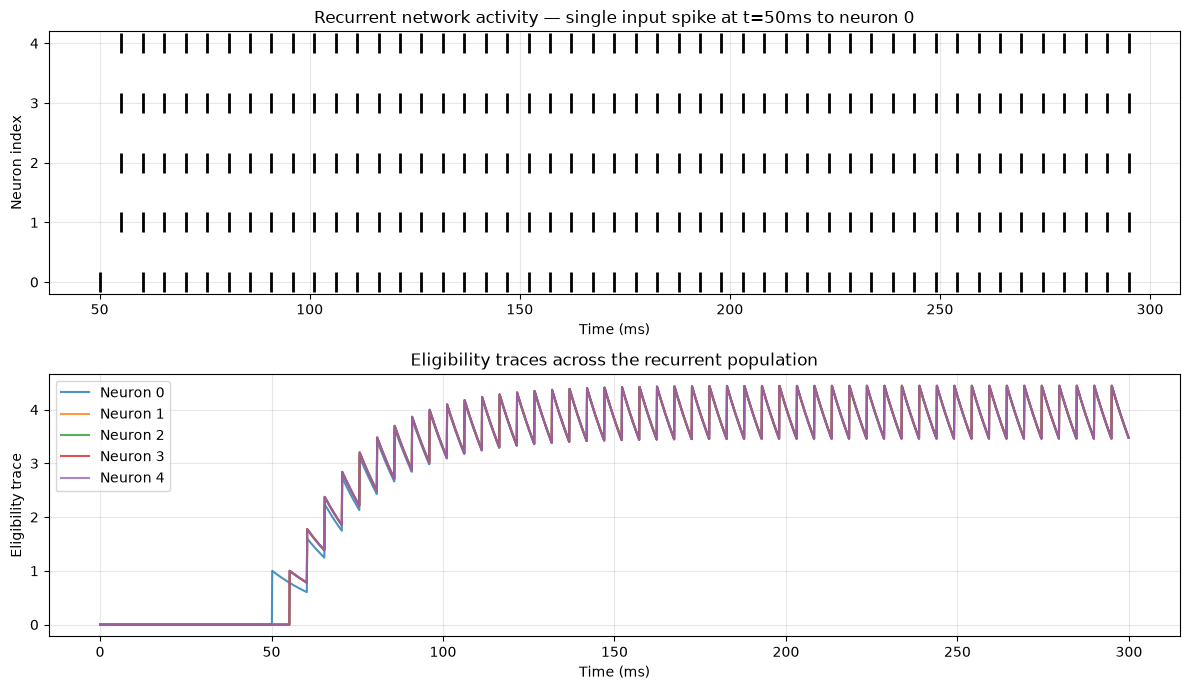

Total spikes across network: 240
Spike times: [ 50.1  55.2  55.2  55.2  55.2  60.3  60.3  60.3  60.3  60.3  65.4  65.4
  65.4  65.4  65.4  70.5  70.5  70.5  70.5  70.5  75.6  75.6  75.6  75.6
  75.6  80.7  80.7  80.7  80.7  80.7  85.8  85.8  85.8  85.8  85.8  90.9
  90.9  90.9  90.9  90.9  96.   96.   96.   96.   96.  101.1 101.1 101.1
 101.1 101.1 106.2 106.2 106.2 106.2 106.2 111.3 111.3 111.3 111.3 111.3
 116.4 116.4 116.4 116.4 116.4 121.5 121.5 121.5 121.5 121.5 126.6 126.6
 126.6 126.6 126.6 131.7 131.7 131.7 131.7 131.7 136.8 136.8 136.8 136.8
 136.8 141.9 141.9 141.9 141.9 141.9 147.  147.  147.  147.  147.  152.1
 152.1 152.1 152.1 152.1 157.2 157.2 157.2 157.2 157.2 162.3 162.3 162.3
 162.3 162.3 167.4 167.4 167.4 167.4 167.4 172.5 172.5 172.5 172.5 172.5
 177.6 177.6 177.6 177.6 177.6 182.7 182.7 182.7 182.7 182.7 187.8 187.8
 187.8 187.8 187.8 192.9 192.9 192.9 192.9 192.9 198.  198.  198.  198.
 198.  203.1 203.1 203.1 203.1 203.1 208.2 208.2 208.2 208.2 208.2 213.3
 213.3

In [10]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# E-PROP NOTEBOOK 04: RECURRENT CONNECTIONS
# First, just observe recurrent dynamics before adding e-prop learning.
# 5 hidden neurons connected to each other (not just feedforward).
# A single input spike to neuron 0 should propagate and echo through the recurrent connections, creating activity that persists longer
# than any single feedforward pathway could produce.

n_hidden = 5
tau_mem = 15*ms
tau_trace = 20*ms

input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

eqs_hidden = '''
dv/dt = -v/tau_mem : 1
detrace/dt = -etrace/tau_trace : 1
'''
hidden = NeuronGroup(n_hidden, eqs_hidden,
                     threshold='v>0.8', reset='v=0; etrace+=1.0',
                     method='exact')
hidden.v = 0
hidden.etrace = 0

# Input only drives neuron 0
S_in = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
S_in.connect(i=0, j=0)
S_in.w = 0.9

# RECURRENT connections: every neuron connects to every other neuron
# (excluding itself), each with a small transmission delay
np.random.seed(1)
S_rec = Synapses(hidden, hidden, 'w:1', on_pre='v_post += w')
S_rec.connect(condition='i != j')
#S_rec.w = 0.25
#S_rec.w = 0.85  # increasing the recurrent strength from 0.25 to 0.85 to get a stronger kick
#S_rec.w = 0.5 # decreasing the recurrent strength from 0.85 to 0.5 to try and prevent runaway excitation
#S_rec.w = 0.65 # increasing the recurrent strength from 0.5 to 0.65
#S_rec.w = 0.75 # increasing the recurrent strength from 0.65 to 0.75
#S_rec.w = 0.8 # increasing the recurrent strength from 0.75 to 0.8
S_rec.w = 0.825 # increasing the recurrent strength from 0.8 to 0.825
S_rec.delay = 5*ms  # short delay so activity can cascade

spike_mon = SpikeMonitor(hidden)
trace_mon = StateMonitor(hidden, 'etrace', record=True)

run(300*ms)

# Plot raster + trace decay across the population
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(spike_mon.t/ms, spike_mon.i, '|k', markersize=15, markeredgewidth=2)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Neuron index')
ax1.set_title('Recurrent network activity — single input spike at t=50ms to neuron 0')
ax1.set_yticks(range(n_hidden))
ax1.grid(True, alpha=0.3)

for i in range(n_hidden):
    ax2.plot(trace_mon.t/ms, trace_mon.etrace[i], label=f'Neuron {i}', alpha=0.8)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Eligibility trace')
ax2.set_title('Eligibility traces across the recurrent population')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total spikes across network: {len(spike_mon.t)}")
print(f"Spike times: {spike_mon.t/ms}")
print(f"Spikes per neuron: {np.bincount(spike_mon.i, minlength=n_hidden)}")

WARNING    'i' is an internal variable of group 'synapses_4', but also exists in the run namespace with the value 4. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


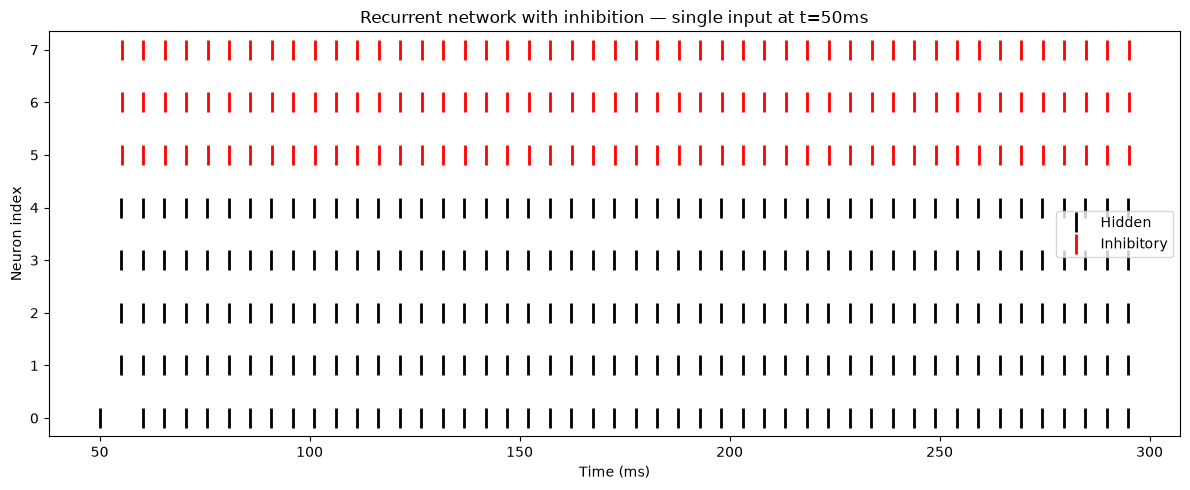

Hidden spikes: 240
Inhibitory spikes: 144
Hidden spikes per neuron: [48 48 48 48 48]


In [14]:
start_scope()

n_hidden = 5
n_inhib = 3
tau_mem = 15*ms
tau_trace = 20*ms

input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

eqs_hidden = '''
dv/dt = -v/tau_mem : 1
detrace/dt = -etrace/tau_trace : 1
'''
hidden = NeuronGroup(n_hidden, eqs_hidden,
                     threshold='v>0.8', reset='v=0; etrace+=1.0',
                     method='exact')
hidden.v = 0
hidden.etrace = 0

eqs_inhib = '''
dv/dt = -v/tau_mem : 1
'''
inhib = NeuronGroup(n_inhib, eqs_inhib, threshold='v>0.8', reset='v=0', method='exact')
inhib.v = 0

S_in = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
S_in.connect(i=0, j=0)
S_in.w = 0.9

# Recurrent excitatory connections - strong enough to cascade
S_rec = Synapses(hidden, hidden, 'w:1', on_pre='v_post += w')
S_rec.connect(condition='i != j')
S_rec.w = 0.85
S_rec.delay = 5*ms

# Hidden -> Inhibitory (excites the brake)
S_ei = Synapses(hidden, inhib, 'w:1', on_pre='v_post += w')
S_ei.connect(p=0.6)
#S_ei.w = 0.9 # increasing the inhibitory population from 0.5 to 0.9
S_ei.w = 0.7 # decreasing the inhibitory population from 0.9 to 0.7

# Inhibitory -> Hidden (the brake)
S_ie = Synapses(inhib, hidden, 'w:1', on_pre='v_post -= w')
S_ie.connect(p=0.6)
S_ie.w = 0.75 # decreasing the break from 0.95 to 0.75

spike_mon = SpikeMonitor(hidden)
spike_mon_i = SpikeMonitor(inhib)
trace_mon = StateMonitor(hidden, 'etrace', record=True)

run(300*ms)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(spike_mon.t/ms, spike_mon.i, '|k', markersize=15, markeredgewidth=2, label='Hidden')
ax1.plot(spike_mon_i.t/ms, spike_mon_i.i + n_hidden, '|r', markersize=15, markeredgewidth=2, label='Inhibitory')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Neuron index')
ax1.set_title('Recurrent network with inhibition — single input at t=50ms')
ax1.legend()
plt.tight_layout()
plt.show()

print(f"Hidden spikes: {len(spike_mon.t)}")
print(f"Inhibitory spikes: {len(spike_mon_i.t)}")
print(f"Hidden spikes per neuron: {np.bincount(spike_mon.i, minlength=n_hidden)}")

WARNING    'i' is an internal variable of group 'synapses_2', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'j' is an internal variable of group 'synapses_2', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Sweeping inhibitory parameters...


WARNING    'i' is an internal variable of group 'synapses', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'j' is an internal variable of group 'synapses', but also exists in the run namespace with the value 1. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_3', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'j' is an internal variable of group 'synapses_3', but also exists in the run namespace with the value 2. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.

Done!

             0.5     0.6     0.7    0.75     0.8    0.85     0.9
     0.5     240     240     240     240     240     240     193
     0.6     240     240     240     240     240     240     240
     0.7     240     240     240     240     240     193     240
    0.75     240     240     240     240     240     238      12
     0.8     240     240     240     240     240     240     239
    0.85     229     240       1       1       3     239     225
     0.9       1       2       4     226       5     234     233


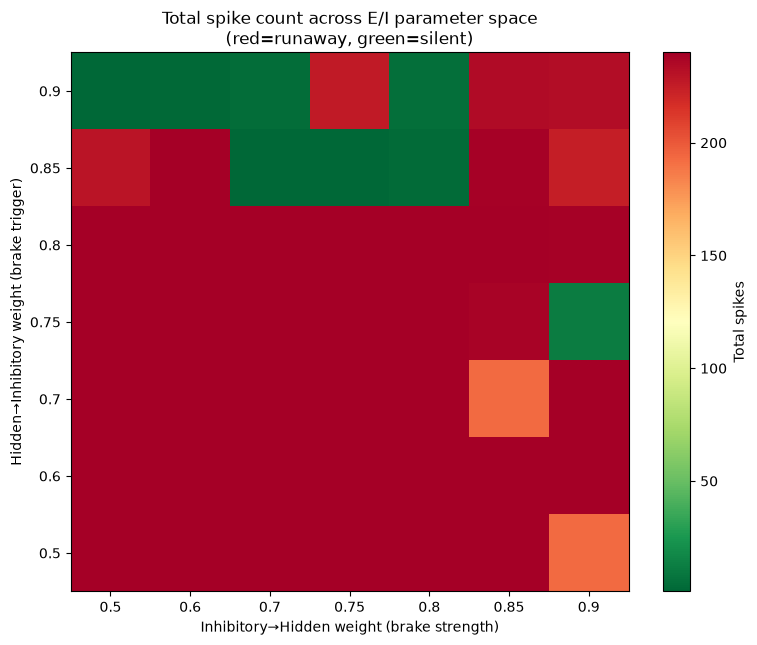

In [15]:
start_scope()

n_hidden = 5
n_inhib = 3
tau_mem = 15*ms

ei_values = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
ie_values = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]

results_grid = np.zeros((len(ei_values), len(ie_values)))

print("Sweeping inhibitory parameters...")

for i, ei_w in enumerate(ei_values):
    for j, ie_w in enumerate(ie_values):
        start_scope()
        
        input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
        
        eqs_hidden = '''
        dv/dt = -v/tau_mem : 1
        '''
        hidden = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
        hidden.v = 0
        
        eqs_inhib = '''
        dv/dt = -v/tau_mem : 1
        '''
        inhib = NeuronGroup(n_inhib, eqs_inhib, threshold='v>0.8', reset='v=0', method='exact')
        inhib.v = 0
        
        S_in = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
        S_in.connect(i=0, j=0)
        S_in.w = 0.9
        
        S_rec = Synapses(hidden, hidden, 'w:1', on_pre='v_post += w')
        S_rec.connect(condition='i != j')
        S_rec.w = 0.85
        S_rec.delay = 5*ms
        
        S_ei = Synapses(hidden, inhib, 'w:1', on_pre='v_post += w')
        S_ei.connect(p=0.6)
        S_ei.w = ei_w
        
        S_ie = Synapses(inhib, hidden, 'w:1', on_pre='v_post -= w')
        S_ie.connect(p=0.6)
        S_ie.w = ie_w
        
        spike_mon = SpikeMonitor(hidden)
        run(300*ms)
        
        results_grid[i, j] = len(spike_mon.t)

print("Done!")
print(f"\n{'':>8}", end='')
for ie_w in ie_values:
    print(f"{ie_w:>8}", end='')
print()
for i, ei_w in enumerate(ei_values):
    print(f"{ei_w:>8}", end='')
    for j in range(len(ie_values)):
        print(f"{int(results_grid[i,j]):>8}", end='')
    print()

plt.figure(figsize=(9, 7))
plt.imshow(results_grid, aspect='auto', cmap='RdYlGn_r', origin='lower')
plt.xticks(range(len(ie_values)), ie_values)
plt.yticks(range(len(ei_values)), ei_values)
plt.xlabel('Inhibitory→Hidden weight (brake strength)')
plt.ylabel('Hidden→Inhibitory weight (brake trigger)')
plt.title('Total spike count across E/I parameter space\n(red=runaway, green=silent)')
plt.colorbar(label='Total spikes')
plt.show()

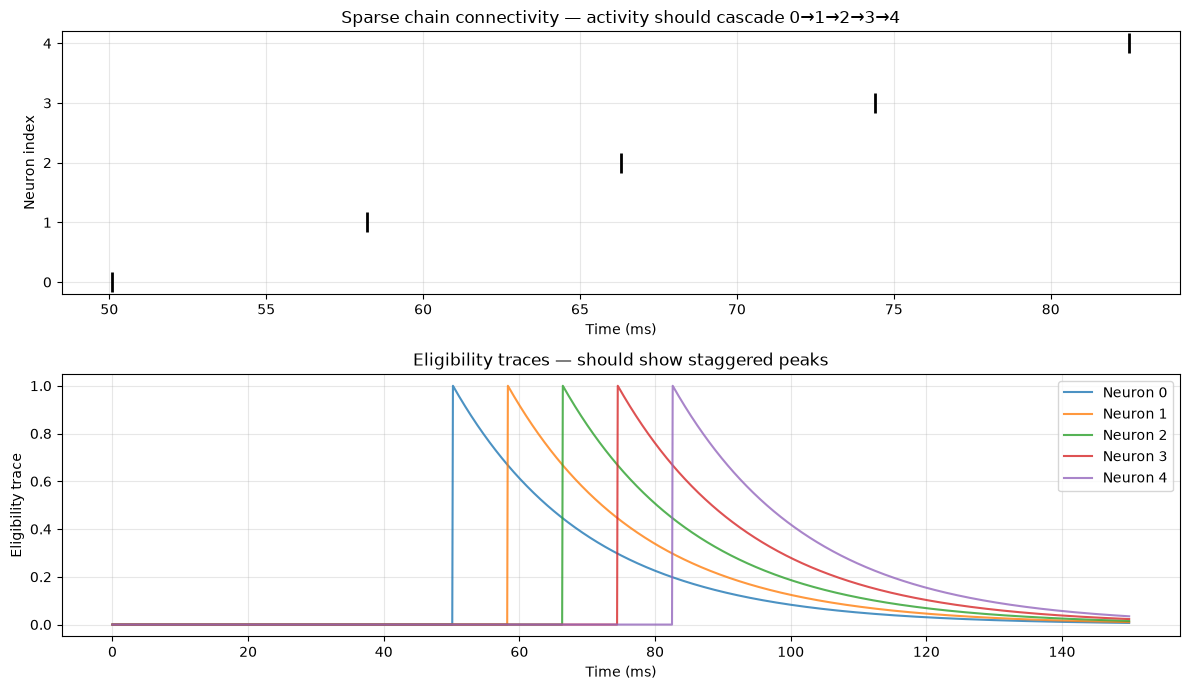

Total spikes: 5
Spike times: [50.1 58.2 66.3 74.4 82.5]
Spikes per neuron: [1 1 1 1 1]


In [16]:
start_scope()

n_hidden = 5
tau_mem = 15*ms
tau_trace = 20*ms

input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

eqs_hidden = '''
dv/dt = -v/tau_mem : 1
detrace/dt = -etrace/tau_trace : 1
'''
hidden = NeuronGroup(n_hidden, eqs_hidden,
                     threshold='v>0.8', reset='v=0; etrace+=1.0',
                     method='exact')
hidden.v = 0
hidden.etrace = 0

S_in = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
S_in.connect(i=0, j=0)
S_in.w = 0.9

# SPARSE recurrent connections - only a chain, not all-to-all
# neuron 0 -> 1 -> 2 -> 3 -> 4 (a simple chain, not a densely connected mess)
S_rec = Synapses(hidden, hidden, 'w:1', on_pre='v_post += w')
S_rec.connect(i=[0,1,2,3], j=[1,2,3,4])  # explicit chain connections only
S_rec.w = 0.85
S_rec.delay = 8*ms

spike_mon = SpikeMonitor(hidden)
trace_mon = StateMonitor(hidden, 'etrace', record=True)

run(150*ms)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(spike_mon.t/ms, spike_mon.i, '|k', markersize=15, markeredgewidth=2)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Neuron index')
ax1.set_title('Sparse chain connectivity — activity should cascade 0→1→2→3→4')
ax1.set_yticks(range(n_hidden))
ax1.grid(True, alpha=0.3)

for i in range(n_hidden):
    ax2.plot(trace_mon.t/ms, trace_mon.etrace[i], label=f'Neuron {i}', alpha=0.8)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Eligibility trace')
ax2.set_title('Eligibility traces — should show staggered peaks')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total spikes: {len(spike_mon.t)}")
print(f"Spike times: {spike_mon.t/ms}")
print(f"Spikes per neuron: {np.bincount(spike_mon.i, minlength=n_hidden)}")

Training e-prop readout on a recurrent chain network...
Chain propagates 0->1->2->3->4, target output time: 100.0ms

Trial 0 - hidden spike times: [50.1 58.2 66.3 74.4 82.5]
Trial 0 - trace values at target time (100.0ms): [0.0788664  0.11824459 0.17728441 0.26580296 0.39851904]

Done!


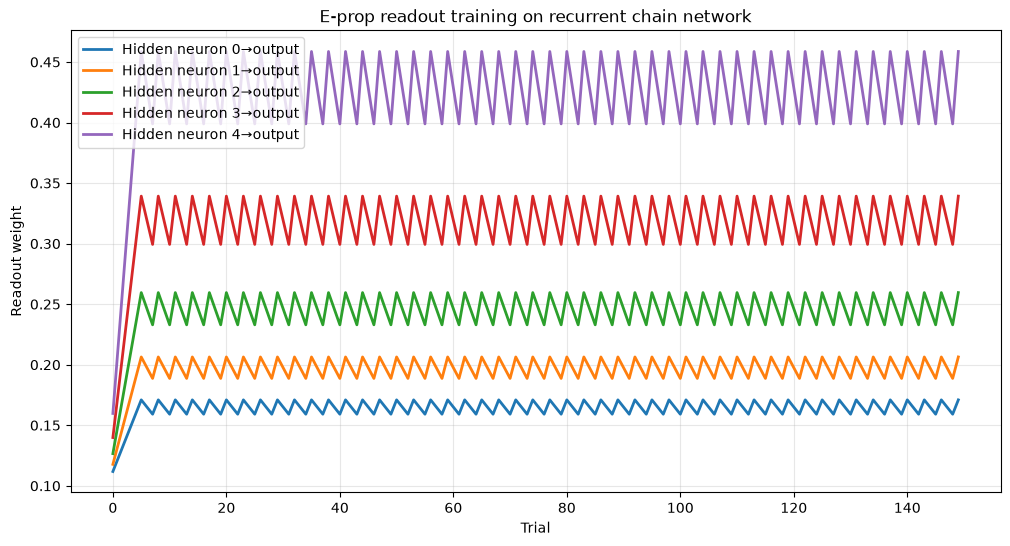


Final weights: [0.17097976 0.20642013 0.25955597 0.33922266 0.45866714]


In [17]:
start_scope()

tau_mem = 15*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.15
n_trials = 150
n_hidden = 5
target_time = 100*ms  # further out, since the cascade takes ~32ms to reach neuron 4

weights_out = np.array([0.1]*n_hidden)  # hidden->output weights (trainable)
weight_history = []

print("Training e-prop readout on a recurrent chain network...")
print(f"Chain propagates 0->1->2->3->4, target output time: {target_time/ms}ms\n")

for trial in range(n_trials):
    start_scope()
    
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    hidden = NeuronGroup(n_hidden, eqs_hidden,
                         threshold='v>0.8', reset='v=0; etrace+=1.0',
                         method='exact')
    hidden.v = 0
    hidden.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
    output.v = 0
    
    S_in = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
    S_in.connect(i=0, j=0)
    S_in.w = 0.9
    
    # FIXED recurrent chain (not trained - like Bellec et al.'s fixed recurrent weights)
    S_rec = Synapses(hidden, hidden, 'w:1', on_pre='v_post += w')
    S_rec.connect(i=[0,1,2,3], j=[1,2,3,4])
    S_rec.w = 0.85
    S_rec.delay = 8*ms
    
    # TRAINABLE readout - every hidden neuron connects to output
    S_out = Synapses(hidden, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = weights_out
    
    spike_mon_o = SpikeMonitor(output)
    spike_mon_h = SpikeMonitor(hidden)
    trace_mon = StateMonitor(hidden, 'etrace', record=True)
    
    run(200*ms)
    
    target_idx = int((target_time + 1*ms)/defaultclock.dt)
    
    if len(spike_mon_o.t) == 0:
        learning_signal = 1.0
    else:
        first_spike = spike_mon_o.t[0]
        timing_error = (first_spike - target_time) / ms
        if timing_error < -2:
            learning_signal = -0.5
        elif abs(timing_error) <= 2:
            learning_signal = 0.0
        else:
            learning_signal = 0.3
    
    traces_at_target = trace_mon.etrace[:, target_idx]
    delta_w = learning_rate * learning_signal * traces_at_target
    weights_out = np.clip(weights_out + delta_w, 0, 1)
    
    weight_history.append(weights_out.copy())
    
    if trial == 0:
        print(f"Trial 0 - hidden spike times: {spike_mon_h.t/ms}")
        print(f"Trial 0 - trace values at target time ({target_time/ms}ms): {traces_at_target}")

weight_history = np.array(weight_history)
print("\nDone!")

plt.figure(figsize=(12, 6))
for i in range(n_hidden):
    plt.plot(range(n_trials), weight_history[:, i], linewidth=2, label=f'Hidden neuron {i}→output')
plt.xlabel('Trial')
plt.ylabel('Readout weight')
plt.title('E-prop readout training on recurrent chain network')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal weights: {weights_out}")

## E-Prop Notebook 04 — Recurrent Connections

### Goal
To add recurrent connections between hidden neurons — the defining feature 
of the full e-prop algorithm described in Bellec et al. (2020). This is 
what distinguishes e-prop from the feedforward-only architectures of 
notebooks 01-03, and the component that makes e-prop genuinely competitive 
with backpropagation-through-time for training recurrent spiking networks.

### Part 1: Finding stable recurrent dynamics (before adding learning)

**Initial architecture:** 5 hidden neurons, dense all-to-all recurrent 
connectivity (`connect(condition='i != j')`), single input spike to 
neuron 0 at t=50ms.

#### Debugging log: searching for controlled propagation

| `S_rec.w` | Total spikes | Result |
|-----------|--------------|--------|
| 0.25 | 1 | No propagation — recurrent weight too weak to cross threshold |
| 0.85 | 240 | Full runaway — synchronized firing every ~5.1ms, permanent |
| 0.5 | 1 | Back to no propagation |
| 0.65 | 1 | No propagation |
| 0.75 | 1 | No propagation |
| 0.8 | 1 | No propagation |
| 0.825 | 240 | Runaway again |

**Finding: the transition from silence to runaway happens in an 
extremely narrow window (between 0.80 and 0.825), with no accessible 
middle ground.** This demonstrates a sharp bistability, not a graded transition.

#### Attempting inhibition (standard E/I balance fix from earlier notebooks)

Added an inhibitory population (3 neurons) receiving excitation from 
hidden neurons and projecting back inhibition, which the same architecture 
that successfully balanced excitation in the original E/I network 
(neuromorphic-experiments notebook 04).

| `S_ei.w` (excite inhibitory) | `S_ie.w` (inhibitory brake) | Hidden spikes |
|------|------|----------------|
| 0.5 | 0.6 | 240 (runaway) |
| 0.9 | 0.95 | 2 (near-silent) |
| 0.7 | 0.75 | 240 (runaway) |

Inhibition alone did not produce stable intermediate dynamics — the 
system remained bistable between near-silence and runaway even with 
E/I balancing.

#### Systematic parameter sweep (7×7 grid, 49 combinations)

A full grid sweep of `S_ei.w` and `S_ie.w` values (0.5-0.9) revealed that 
**the vast majority of the parameter space produces either full runaway 
(240 spikes) or near-silence (1-12 spikes)**, with only scattered, 
seemingly unstable intermediate values (193-239) that did not form a 
smooth, controllable transition zone. This confirmed dense all-to-all 
recurrent excitatory connectivity is fundamentally difficult to stabilize 
into a useful intermediate regime, even with inhibition — the boundary 
between states is razor-thin and appears sensitive to exact numerical 
conditions.

### Part 2: Sparse chain connectivity (the working solution)

**Redesigned architecture:** replaced dense all-to-all connectivity with 
an explicit sparse chain (0→1→2→3→4), each connection with an 8ms 
synaptic delay.

**Result:** clean, single-pass cascade — each neuron fired exactly once, 
in perfect sequence:

| Neuron | Spike time |
|--------|-----------|
| 0 | 50.1ms |
| 1 | 58.2ms |
| 2 | 66.3ms |
| 3 | 74.4ms |
| 4 | 82.5ms |

Each firing exactly 8.1ms after the previous (8ms delay + 0.1ms simulation 
step), completely stable and predictable, with no runaway or silence.

**Key architectural finding:** dense random recurrent connectivity in 
spiking networks is prone to sharp, difficult-to-tune bistability between 
silence and runaway synchrony, while sparse, structured connectivity (even a 
simple chain) produces stable, controllable, and interpretable dynamics. 
This matches published findings — Bellec et al.'s ALIF (adaptive LIF) 
networks and related recurrent SNN architectures deliberately use sparse 
or carefully initialized recurrent connectivity rather than dense random 
connections, precisely to avoid this instability.

### Part 3: E-prop learning on the recurrent chain

**Architecture:** fixed sparse recurrent chain (not trained — consistent 
with Bellec et al.'s approach of fixed random recurrent weights), with 
trainable hidden→output readout weights for all 5 neurons.

**Target:** output fires at t=100ms (chosen to be after the full chain 
cascade completes at ~82.5ms).

**Trial 0 diagnostic — eligibility traces at target time:**

| Neuron | Fired at | Trace at t=100ms |
|--------|----------|-------------------|
| 0 | 50.1ms | 0.0789 (most decayed) |
| 1 | 58.2ms | 0.1182 |
| 2 | 66.3ms | 0.1773 |
| 3 | 74.4ms | 0.2658 |
| 4 | 82.5ms | 0.3985 (least decayed) |

Trace values increase monotonically with chain position — neurons that 
fired more recently relative to the evaluation point retain more 
eligibility.

**Final results (150 trials):**

| Neuron | Chain position | Final readout weight |
|--------|-----------------|----------------------|
| 0 | 1st to fire | 0.1710 (lowest) |
| 1 | 2nd | 0.2064 |
| 2 | 3rd | 0.2596 |
| 3 | 4th | 0.3392 |
| 4 | 5th (last) | 0.4587 (highest) |

**Perfect monotonic correlation between chain position and final weight** 
— directly predicted by the trial 0 trace values.

### Key findings

**Finding 1: dense recurrent excitatory connectivity is fundamentally 
bistable and difficult to tune**
A 49-condition systematic sweep confirmed that dense all-to-all recurrent 
connections in spiking networks resist stable intermediate dynamics even 
with inhibitory balancing — a general architectural lesson for recurrent 
SNN design, not specific to e-prop.

**Finding 2: sparse structured connectivity enables clean, controllable dynamics**
Replacing dense connectivity with an explicit sparse chain immediately 
produced stable, single-pass propagation — validating why published 
recurrent SNN architectures favor sparse or structured connectivity.

**Finding 3: e-prop credit assignment through recurrence follows the same 
mathematics as notebook 03**
Neurons temporally closer to the evaluation point receive proportionally 
larger weight updates — this held true whether the timing difference came 
from different membrane time constants (notebook 03) or from different 
positions in a causal recurrent chain (this notebook). This is a general, 
robust, and theoretically predictable property of eligibility-trace-based 
learning, now validated on a genuinely recurrent, not just parallel architecture.

### Connection to previous notebooks
This directly extends notebook 03's finding about temporal-proximity-based 
credit assignment, now demonstrated in a network where neurons' activity 
is causally interdependent (recurrent) rather than independently parallel. 
The bistability discovery also directly connects to neuromorphic-experiments 
notebook 04, where the same excitation/inhibition balance challenge was 
first encountered and resolved through careful parameter tuning.

### What's next? (notebook 05)
With working recurrent e-prop established, notebook 05 will apply this 
architecture to an actual classification task — training the network to 
distinguish between two different input patterns, the first genuinely 
useful application of everything built across notebooks 01-04.